# My Notes

- **Course**: Qubits, entanglement and matrix product sates
- **Author**: Théo HUET
- **Date**: 16/01/2026 - 30/01/2026

# TD1 - One, two and many qubits: Density matrices, purity and entanglement

## Exercice 1 : Time evolution of entanglement

We consider a system of **two interacting qubits** in the state :

$|\Psi \rangle = |01 \rangle$

The **Hamiltonian** is given by:

$ H = - J \sigma_x \otimes \sigma_x + \frac{\pi}{4} \sigma_y \otimes Id + \frac{1}{2} Id \otimes \sigma_z $

We study the unitary dynamics of a two-qubit system
and analyze the generation of entanglement.

### Initialisation :

In [ ]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

import constants
from utils import *

# Physical parameters
J = 1.0

def initialization(J : float) :
  # Hamiltonian
  H = -J*np.kron(constants.X,constants.X) + np.pi/4 * np.kron(constants.Y,constants.I) + 0.5 * np.kron(constants.I,constants.Z)

  # compute evolution operator
  U = expm(1j*H*constants.dt)
  Ud = np.conj(np.transpose(U)) #U dagger

  # initialization of lists for measurements
  purity, entropy_A, averageEnergy = [], [], []

  return purity, entropy_A, averageEnergy, H, U, Ud

# initial state
va = np.array([1,0]) #|0>
vb = np.array([0,1]) #|1>
psi0 = np.kron(va,vb) #|01>
rho0 = compute_rho(psi0) #|01><01|


### Calculation of quantities to be measured

**Average energy calculation :**

$\langle H \rangle = Tr(H\rho(t))$

**Entropy calculation :**

$S_A(t) = -Tr(\rho_A(t) \log(\rho_A(t)))$

but we will use :

$S_A(t) = - \Sigma^2_{i=1} \lambda_i(t) \log(\lambda_i(t))$  *where the* $\lambda_i(t)$ *are the eigenvalues of* $\rho_i(t)$.

To avoid problems with the log, we will use an $\epsilon = 10^{-8}$ in the eigenvalues expression : $\lambda'_i(t) = |\lambda_i(t)| + \epsilon$

**Purity calculation :**

$P_A = Tr(\rho_A(t)^2)$

### Discretized temporary evolution loop :

At each time step $t_n$, we calculate $\rho(t_n) = U \rho(t_{n-1})U^\dagger $.

In [ ]:
def evolution_loop(J : float, rho0 : np.array, Nt : int) :
  # initialization of all the parameters we will need
  purity, entropy_A, averageEnergy, H, U, Ud = initialization(J)

  rho = rho0
  for _ in range(Nt) :
    # Unitary time evolution of the density matrix
    rho = U @ rho @ Ud
    rho_A = partial_trace_A(rho) # partial trace of rho(t)

    # average energy calculation (to verify that it is conserved and that our simulation is stable)
    averageEnergy.append(measurements_averageEnergy(H, rho).real)

    # entropy calculation
    entropy_A.append(measurements_entropy(rho_A).real)

    # purity calculation
    purity.append(measurements_purity(rho_A).real)
  return purity, entropy_A, averageEnergy

purity, entropy_A, averageEnergy = evolution_loop(J, rho0, constants.Nt)

### Plot :

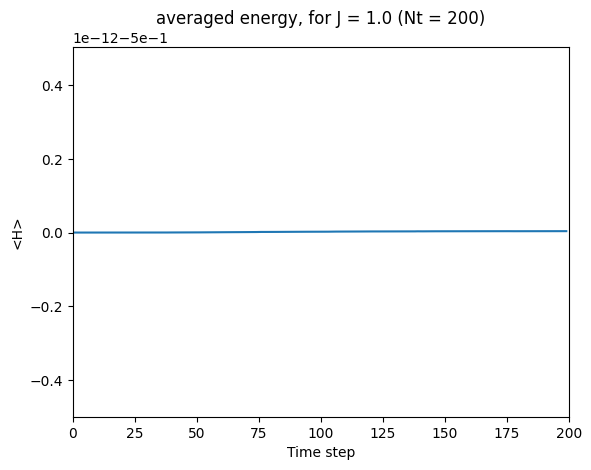

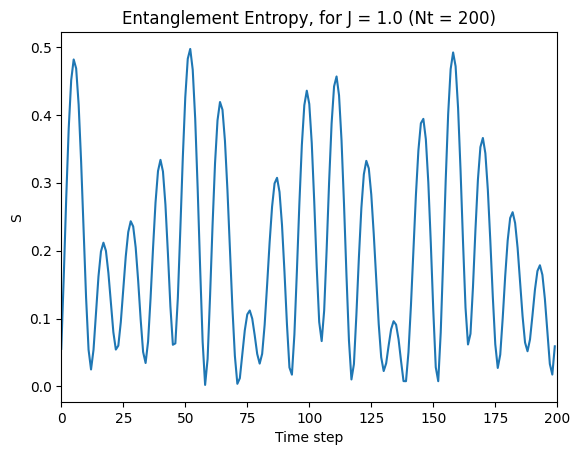

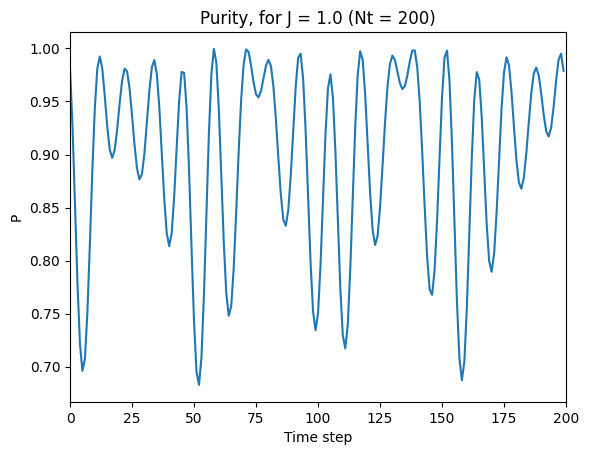

In [ ]:
def plot_results(J : float,
                 y1 : list, y2: list = [],
                 title : str = "" , ylabel : str = "y" ,
                 show_plot=False) :
  plt.figure()
  plt.plot(y1)
  plt.plot(y2,alpha=0.2)
  plt.xlabel("Time step")
  plt.ylabel(ylabel)
  plt.title(title + ", for J = " + str(J) + " (Nt = " + str(constants.Nt) + ")")
  plt.xlim(0,constants.Nt)
  if show_plot :
    plt.show()

plot_results(J, averageEnergy, title="averaged energy", ylabel="<H>", show_plot=True) # energy conservation figure
plot_results(J, entropy_A, title="Entanglement Entropy", ylabel="S", show_plot=True) # entropy figure
plot_results(J, purity, title="Purity", ylabel="P", show_plot=True) # purity figure


The entanglement entropy exhibits strong temporal oscillations,
which are characteristic of unitary dynamics in a finite quantum system.

Due to the highly oscillatory behavior of the observables,
we also compute their time-averaged values defined as:

$\overline{f}(T) = \frac{1}{T} \int_0^T f(t)\, dt$

### Time averaged values as function of T :

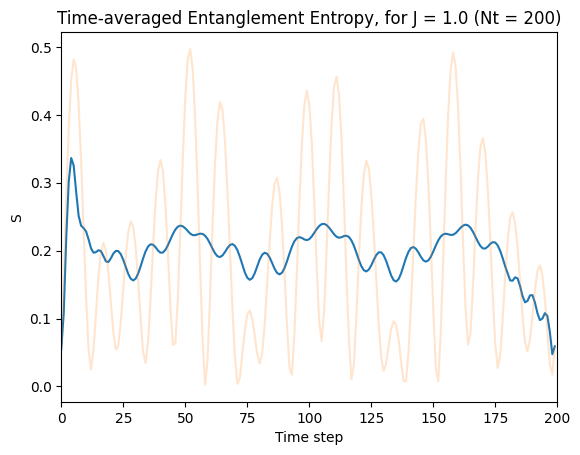

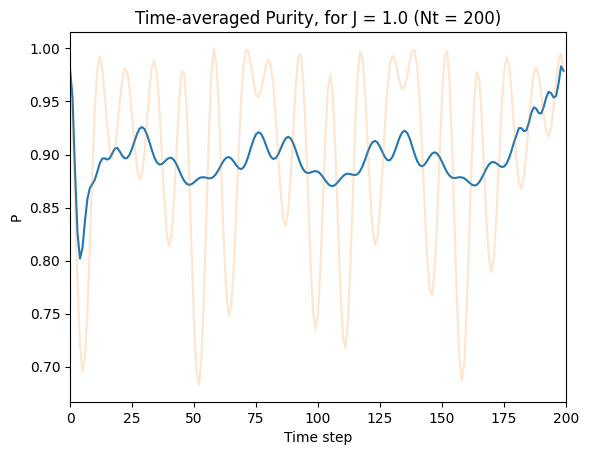

In [ ]:
def time_averaged_values(averageEnergy : list, entropy_A : list, purity : list) :
  averageEnergy_T, entropy_A_T, purity_T = [], [], [] # initialization of lists for measurements

  T = int(constants.Nt*constants.dt) #notre rayon pour faire nos moyennes

  for n in range(constants.Nt):
    if n == 0 : # si on est au debut on ne pourra pas faire de moyenne on prends la premiere valeur
      Energy_average_temp = averageEnergy[0]
      entropy_A_average_temp = entropy_A[0]
      purity_average_temp = purity[0]
    elif n == constants.Nt-1: # si on est a la fin on ne pourra pas faire de moyenne on prends la derniere valeur
      Energy_average_temp = averageEnergy[-1]
      entropy_A_average_temp = entropy_A[-1]
      purity_average_temp = purity[-1]
    else :
      if n < T : #si on est trop pret du debut on prend comme rayon la distance au bord
        R = n
      elif n + T > constants.Nt : #si on est trop pret de la fin on prend comme rayon la distance au bord
        R = constants.Nt - n
      else :
        R = T
      Energy_average_temp = np.mean(averageEnergy[n - R: n + R])
      entropy_A_average_temp = np.mean(entropy_A[n - R: n + R])
      purity_average_temp = np.mean(purity[n - R: n + R])

    averageEnergy_T.append(Energy_average_temp)
    entropy_A_T.append(entropy_A_average_temp)
    purity_T.append(purity_average_temp)
  return averageEnergy_T, entropy_A_T, purity_T

averageEnergy_T, entropy_A_T, purity_T = time_averaged_values(averageEnergy, entropy_A, purity)

#plot_results(J, averageEnergy_T, averageEnergy, title="Time-averaged energy", ylabel="<H>", show_plot=True) # Time-averaged energy conservation figure
plot_results(J, entropy_A_T, entropy_A, title="Time-averaged Entanglement Entropy", ylabel="S", show_plot=True) # Time-averaged entropy figure
plot_results(J, purity_T, purity, title="Time-averaged Purity", ylabel="P", show_plot=True) #Time-averaged purity figure


The time-averaged observables display a much smoother behavior
and tend towards stationary values.
This averaging allows us to extract the long-time properties of the system.

To further our analysis, we now extend the simulation to a range of coupling strengths $J$. By comparing these different regimes, we can observe how the interaction strength dictates the speed of decoherence and the stabilization levels of our observables. The following animation illustrates this transition across multiple values of $J$.

### A range of coupling strengths $J$ :


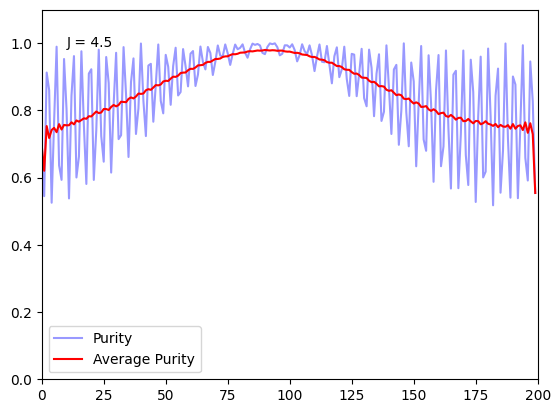

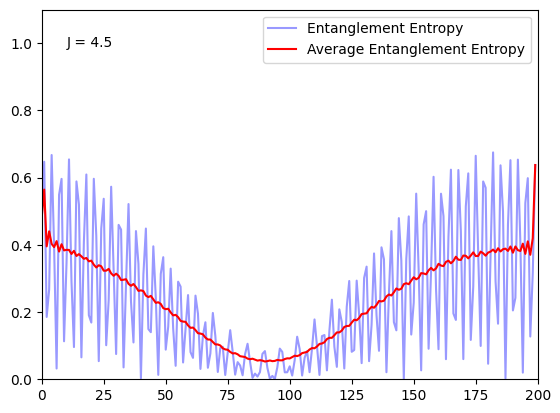

In [ ]:
from matplotlib.animation import FuncAnimation

# Listes pour stocker TOUTES les données de chaque J
all_purity, all_purity_T = [], []
all_averageEnergy, all_averageEnergy_T = [], []
all_entropy_A, all_entropy_A_T = [], []

all_J_values = np.arange(-5, 5, 0.5) # tout les J que l'on va tester
for J in all_J_values :
  purity, entropy_A, averageEnergy = evolution_loop(J, rho0, constants.Nt)

  averageEnergy_T, entropy_A_T, purity_T = time_averaged_values(averageEnergy, entropy_A, purity)

  all_purity.append(purity)
  all_purity_T.append(purity_T)
  all_averageEnergy.append(averageEnergy)
  all_averageEnergy_T.append(averageEnergy_T)
  all_entropy_A.append(entropy_A)
  all_entropy_A_T.append(entropy_A_T)

def plot_results_animation(all_J_values : list,
                           y1 : list, y2: list,
                           title : str = "" ,
                           save_plot = False, show_plot=False) :
  fig, ax = plt.subplots()
  line1, = ax.plot([], [], label=title, color="blue", alpha=0.4)
  line2, = ax.plot([], [], label= "Average " + title, color="red")
  text_j = ax.text(0.05, 0.9, '', transform=ax.transAxes)

  def update(frame):
    # 'frame' est l'index de la simulation (index de J)
    line1.set_data(range(constants.Nt), y1[frame])
    line2.set_data(range(constants.Nt), y2[frame])
    text_j.set_text(f'J = {all_J_values[frame].round(2)}')
    return line1, line2, text_j

  ax.set_xlim(0, constants.Nt)
  ax.set_ylim(0, 1.1)
  ax.legend()

  # Création de l'animation
  ani = FuncAnimation(fig, update, frames=len(all_J_values), interval=500, blit=True)
  if save_plot :
    title = title.replace(" ", "_")
    title = "td1_ex1_plot_" + title + ".gif"
    ani.save(title, writer='pillow')
  if show_plot :
    plt.show()

save_plot = True # Pour sauvegarder en GIF
show_plot = False

plot_results_animation(all_J_values,all_purity, all_purity_T, title="Purity", save_plot = save_plot, show_plot = show_plot)
plot_results_animation(all_J_values,all_entropy_A, all_entropy_A_T, title="Entanglement Entropy", save_plot = save_plot, show_plot = show_plot)

To view the animations properly, please go to the associated [figures folder](https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/tree/main/figures) and search the gif.

---

## Exercice 2 : Entanglement area law and critical scaling

Now we have L qubits with the transverse fiel Ising Hamiltonian with PBC :

$H = \Sigma^L_{j=1} (\sigma^z_j\sigma^z_{j+1} + h\sigma^x_j) \quad$ and $\quad \sigma^\alpha_{L+1} \equiv \sigma^\alpha_{1}$

We want to observe an area law in the gapped phases $|h| \neq 1$, and the critical scaling at $|h| = 1$.


In [ ]:
import numpy as np
from scipy import sparse, linalg
import matplotlib.pyplot as plt

import constants
from utils import *

In [ ]:
def compute_H(L : int, h : float) : # calcul de l'Hamiltonien
  H = sparse.csr_matrix((2**L,2**L), dtype=complex)
  for j in range(L) :
    next_j = (j+1) % L # PBC L+1 = 0

    term_zz = np.array([[1]])
    term_x  = np.array([[1]])

    for site in range(L) :
      if site == j :
        op_zz = constants.Z
        op_x = constants.X
      elif site == next_j :
        op_zz = constants.Z
        op_x = constants.I
      else :
        op_zz = constants.I
        op_x = constants.I

      term_zz = np.kron(term_zz, op_zz)
      term_x = np.kron(term_x, op_x)

    H += term_zz + h * term_x
  return H

def SVD_method(v : np.array, L : int, ell : int) :
  dimHA = 2**ell
  dimHB = 2**(L-ell)
  vR = v.reshape((dimHA,dimHB))
  s = linalg.svdvals(vR) # calcul les singular value
  return s

### Output 1.A

In [ ]:
L = 2 # nombre de Qubit dans le probleme
h = 1 # contribution du champs magnétique

H = compute_H(L,h)
E0, v0 = ground_state(H)

# Méthode 1 :
rho0 = compute_rho(v0)
rho_A = partial_trace_A(rho0)
entropy_A = measurements_entropy(rho_A)

# Méthode 2 :
ell = L//2
s = SVD_method(v0, L, ell)
entropy_A_SVD = measurements_entropy_SVD(s)

print(f"Output 1.A, for L={L}, h={h}:\n")
print("Entropy computed with method 1 (classic): ", round(entropy_A,5))
print("Entropy computed with method 2 (SVD)    : ", round(entropy_A_SVD,5))
print("\nDifference : ", abs(entropy_A - entropy_A_SVD))

Output 1.A, for L=2, h=1:

Entropy computed with method 1 (classic):  0.4165
Entropy computed with method 2 (SVD)    :  0.4165

Difference :  4.996003610813204e-16


The same results are obtained with both methods, the difference in this case is negligible ($10^{-16}$).

### Output 1.B

In [ ]:
L = 6 # nombre de Qubit dans le probleme

eigenValues_list = []
gaps = []
h_list = np.arange(0, 2.1, 0.1)

for h in h_list :
  H = compute_H(L,h)
  if L > 10 :
    eigenValues, _ = sparse.linalg.eigsh(H, k=4, which='SA') # on cherche peu de vp si dimH est trop grand
  else :
    eigenValues = np.linalg.eigh(H)[0]
  eigenValues = np.sort(eigenValues) # pour avoir [E0, E1,...]

  eigenValues_list.append(eigenValues)
  gaps.append(eigenValues[1] - eigenValues[0])

Output 1.B, for L=6:



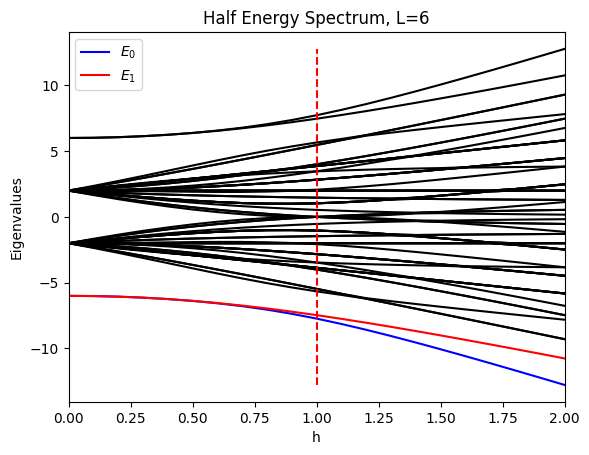

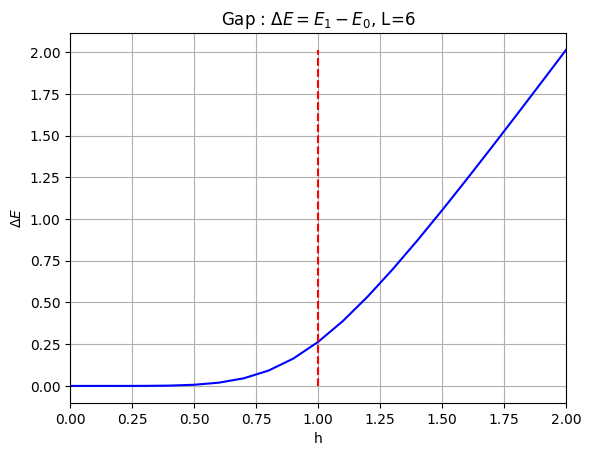

In [ ]:
print(f"Output 1.B, for L={L}:\n")

energies_list = np.array(eigenValues_list).T

plt.figure()
for i, energy in enumerate(energies_list):
    if i == 0:
        color = "blue"
        label = "$E_0$"
    elif i == 1:
        color = "red"
        label = "$E_1$"
    else:
        color = "black"
        label = ""
    plt.plot(h_list, energy, color=color, label=label)
plt.legend()
plt.vlines(x=1, ymin=np.min(eigenValues_list), ymax=np.max(eigenValues_list), colors='red', linestyles='--')
plt.xlim(0, 2)
#plt.ylim(np.min(eigenValues_list), 0)
plt.xlabel("h")
plt.ylabel("Eigenvalues")
plt.title(f"Half Energy Spectrum, L={L}")
plt.show()

plt.figure()
plt.plot(h_list, gaps, color="blue")
plt.vlines(x=1, ymin=0, ymax=np.max(gaps), colors='red', linestyles='--')
plt.xlim(0, 2)
plt.xlabel("h")
plt.ylabel("$\\Delta E$")
plt.title(f"Gap : $\\Delta E = E_1 - E_0$, L={L}")
plt.grid()
plt.show()


For $L=6$, the energy gap is minimal at $h=0$, where the system exhibits a ground-state degeneracy due to the $Z_2$ symmetry of the ferromagnetic phase ($|\uparrow \uparrow \uparrow \uparrow \uparrow \uparrow >$ is equivalent to $|\downarrow \downarrow \downarrow \downarrow \downarrow \downarrow >$).

Although the thermodynamic critical point is at $h=1$, for finite size the gap does not close there. instead, finite-size effects smooth out the transition and prevent a true gap closing.

### Output 2

In [ ]:
L = 10 # nombre de Qubit dans le probleme
ells = np.arange(1, L) # liste des valeurs de ell
hs = [1., 0.1] # valeur 'critique'

S_h = {}
for h in hs :
  H = compute_H(L,h)
  _, v0 = ground_state(H)

  entropy_A = []
  for ell in ells :
    s = SVD_method(v0, L, ell)
    entropy_A.append(measurements_entropy_SVD(s))

  S_h[h] = np.array(entropy_A)

Output 2, for L=10:



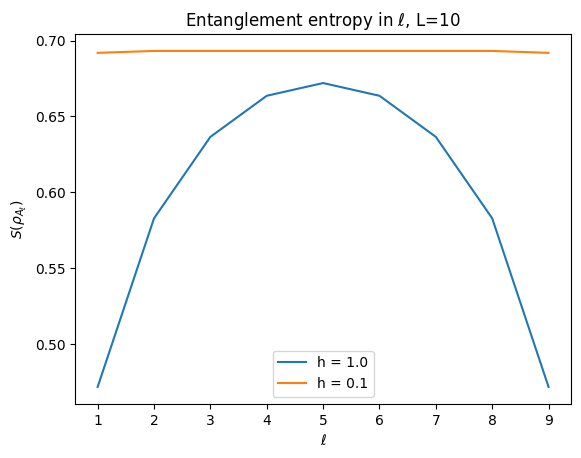

In [ ]:
print(f"Output 2, for L={L}:\n")

plt.figure()
for h in hs:
    plt.plot(ells, S_h[h], label=f"h = {h}")
plt.xlabel("$\\ell$")
plt.ylabel("$S(\\rho_{A_\\ell})$")
plt.title(f"Entanglement entropy in $\\ell$, L={L}")
plt.legend()
plt.show()

#plt.figure()
#for h in hs:
#    plt.plot(np.log(ells), S_h[h], label=f"h = {h}")
#plt.xlabel(r"$log \\ell$")
#plt.ylabel(r"$S(\\rho_{A_\ell})$")
#plt.title(f"Entanglement entropy in $log \\ell$, L={L}")
#plt.legend()
#plt.show()

For $\ell < L/2$ at $h=1$ we need to have :
$$S(\rho_{A_\ell}) = \frac{c}{3} log\ell + \kappa$$

With the theoretical thermodynamic-limit value $c = 1/2$.

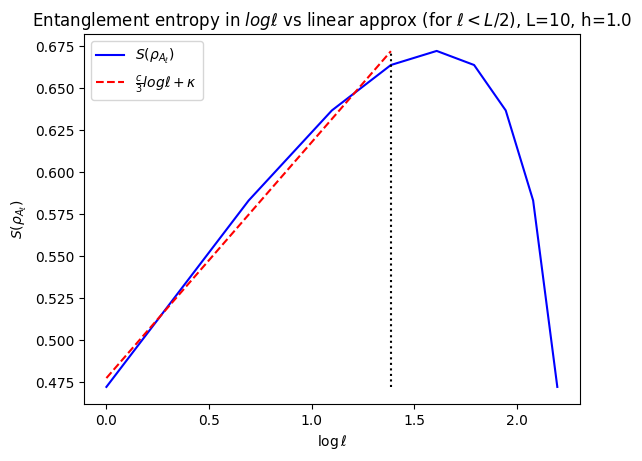

Estimated central charge: 0.42122076766294814 (theoretical value = 1/2)
Error : 0.07877923233705186


In [ ]:
h = 1.
S_1 = S_h[h]

x = np.log(np.arange(1, L//2))

[a, k] = np.polyfit(x, S_1[:len(x)], 1)
c = a*3

plt.figure()
plt.plot(np.log(ells), S_1, color='blue', label="$S(\\rho_{A_\\ell})$")
plt.plot(x, x * a + k, color='red', linestyle='--', label="$\\frac{c}{3} log\\ell + \\kappa$")
plt.vlines(np.log(L//2-1), np.min(S_1), np.max(S_1), color='black', linestyle=':', label='')
plt.legend()
plt.xlabel(r"$\log \ell$")
plt.ylabel(r"$S(\rho_{A_\ell})$")
plt.title(f"Entanglement entropy in $log \\ell$ vs linear approx (for $\\ell<L/2$), L={L}, h={h}")
plt.show()

print("Estimated central charge:", c, "(theoretical value = 1/2)")
print("Error :", np.abs(c-0.5))

We are very far from the thermodynamic limit, so an error of the order of $10^{-2}$ is quite acceptable.

### Output 3

In [ ]:
def haar_random_unitary(N, rng=None) :
    rng = np.random.default_rng() if rng is None else rng

    # complex Ginibre matrix
    Z = (rng.normal(size=(N, N)) + 1j * rng.normal(size=(N, N))) / np.sqrt(2.0)

    # QR decomposition
    Q, R = np.linalg.qr(Z)

    # Phase-fix for Haar distribution
    d = np.diag(R)
    ph = d / np.abs(d)
    U = Q * ph.conj() # multiply columns by conjugate phases

    return U

# parameter
L = 10
h = 1

# create the state |00...0>
state0 = np.array([1, 0])
psi0 = state0
for i in range(L-1) :
    psi0 = np.kron(psi0,state0)

# creation of a random state
U = haar_random_unitary(2**L)
psi = U @ psi0

# compute the entropy_A_ell
ells = np.arange(0, L+1)
entropy_A = []
for ell in ells :
    s = SVD_method(v0, L, ell)
    entropy_A.append(measurements_entropy_SVD(s))
S_h = np.array(entropy_A)

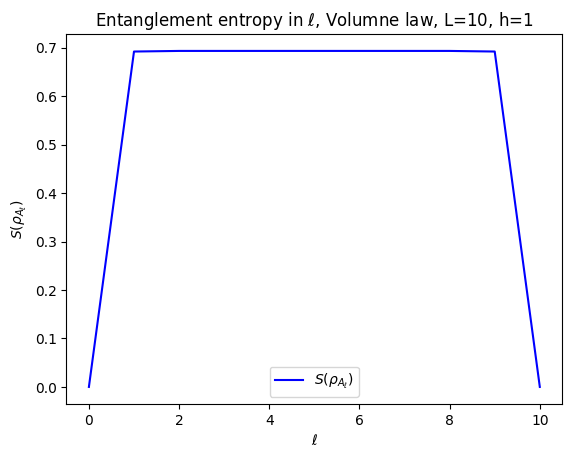

In [ ]:
plt.figure()
plt.plot(ells, S_h, color='blue', label='$S(\\rho_{A_\\ell})$')
plt.xlabel("$\\ell$")
plt.ylabel("$S(\\rho_{A_\\ell})$")
plt.title(f"Entanglement entropy in $\\ell$, Volumne law, L={L}, h={h}")
plt.legend()
plt.show()

We verify a volume law.

---

# References

- Jacopo DE-NARDIS's course on Quasi-exact numerical method for quantum system (Master 2)
- [Numpy documentation](https://numpy.org/doc/stable/)
- [Scipy documentation](https://docs.scipy.org/doc/scipy/)
- [Matplotlib documentation](https://matplotlib.org/stable/index.html)